In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import SVC
from xgboost import XGBClassifier
import shap
import eli5
from eli5.sklearn import PermutationImportance
import warnings

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521729 entries, 0 to 521728
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             521729 non-null  int64  
 1   plant_name             521729 non-null  int64  
 2   timestamp              521729 non-null  object 
 3   wind_speed             521729 non-null  float64
 4   turbulence_intensity   521729 non-null  float64
 5   nacelle_direction      521729 non-null  float64
 6   rotor_speed            521729 non-null  float64
 7   generator_speed        521729 non-null  float64
 8   blade_angle_1          521729 non-null  float64
 9   blade_angle_2          521729 non-null  float64
 10  blade_angle_3          521729 non-null  float64
 11  power                  521729 non-null  float64
 12  cosphi                 521729 non-null  float64
 13  temp_environment       521729 non-null  float64
 14  generator_temperature  521729 non-nu

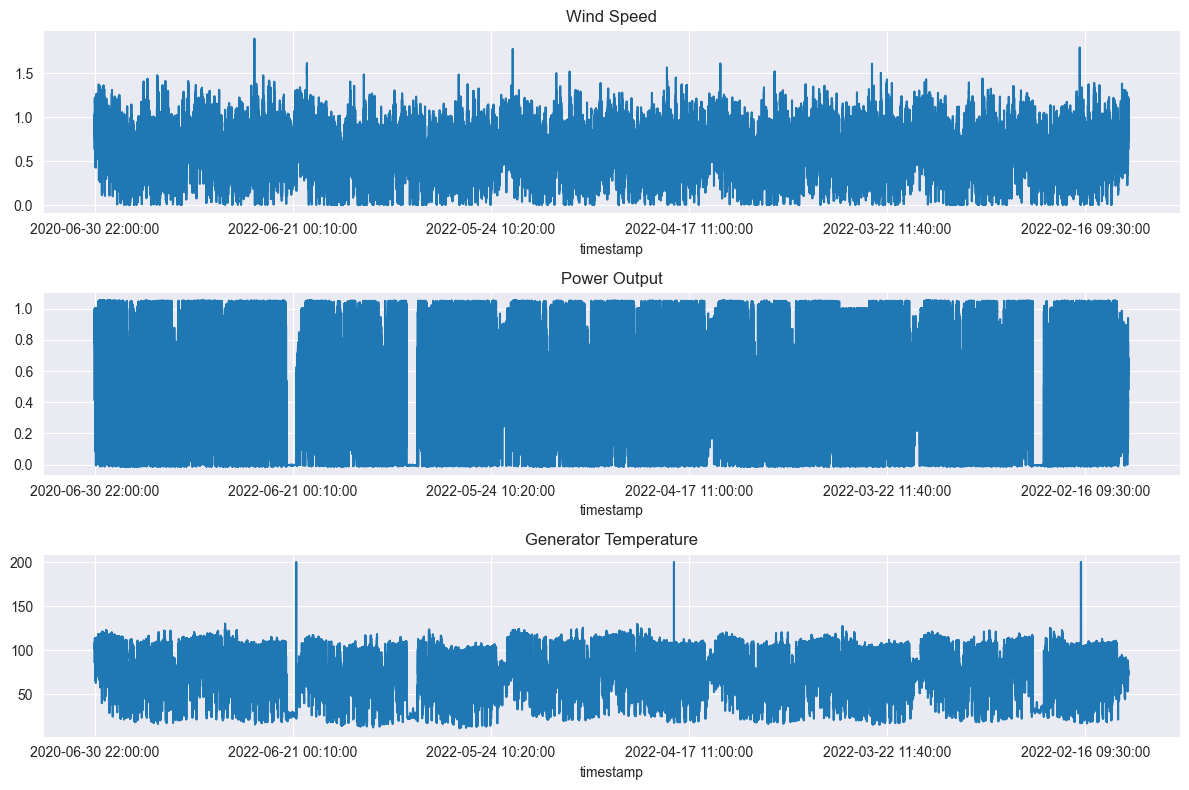

In [2]:
# Load data
data = pd.read_csv('wedowind.csv')
# Basic info
print(data.info())
print(data.describe())

# Check missing values
print(data.isnull().sum())

# Plot time series of key parameters
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
data.set_index('timestamp')['wind_speed'].plot(ax=axes[0], title='Wind Speed')
data.set_index('timestamp')['power'].plot(ax=axes[1], title='Power Output')
data.set_index('timestamp')['generator_temperature'].plot(ax=axes[2], title='Generator Temperature')
plt.tight_layout()
plt.show()

In [3]:
warnings.filterwarnings('ignore')
%matplotlib inline

In [4]:
data.drop('Unnamed: 0', axis=1, inplace=True)  # Remove unnecessary index column

In [5]:
# Display basic info
print("Data Shape:", data.shape)
print("\nFirst 5 rows:")
display(data.head())

Data Shape: (521729, 24)

First 5 rows:


,plant_name,timestamp,wind_speed,turbulence_intensity,nacelle_direction,rotor_speed,generator_speed,blade_angle_1,blade_angle_2,blade_angle_3,...,break_temperature,temp_hydraulic_oil,bearing_temperature,hydraulic_pressure,gear_pressure,wind_direction,wind_speed_reference,airpressure,humidity,errorcode
0,109,2020-06-30 22:00:00,0.860506,0.080801,234.696091,0.990921,0.961606,-0.062965,-0.106202,-0.112470,...,45.000000,40.150250,47.0,235.908493,2.400330,213.934799,0.782716,1014.59998,74.624497,0
1,109,2020-06-30 22:10:00,0.865157,0.074726,235.470120,0.997082,0.967419,-0.793285,-0.827960,-0.829857,...,45.000000,40.464329,47.0,236.166901,2.379390,214.241402,0.761978,1014.77002,74.582703,0
2,109,2020-06-30 22:20:00,0.808986,0.096443,235.101688,0.967709,0.938936,-1.703292,-1.808793,-1.841423,...,45.000000,40.438419,47.0,235.855301,2.394322,215.171001,0.814720,1014.84003,74.268601,0
3,109,2020-06-30 22:30:00,0.723018,0.086718,232.358898,0.880575,0.854544,-2.288805,-2.406158,-2.461918,...,44.375500,40.123749,47.0,236.072601,2.468943,216.096600,0.823528,1014.94000,74.165703,0
4,109,2020-06-30 22:40:00,0.633929,0.084539,231.490791,0.782344,0.759087,-2.287480,-2.403952,-2.462317,...,43.324451,39.623402,47.0,235.691193,2.556490,216.132900,0.815392,1015.09998,74.023102,0


In [6]:
# Basic statistics
print("\nDescriptive Statistics:")
display(data.describe())

# Check for missing values
print("\nMissing Values:")
display(data.isnull().sum())



Descriptive Statistics:


,plant_name,wind_speed,turbulence_intensity,nacelle_direction,rotor_speed,generator_speed,blade_angle_1,blade_angle_2,blade_angle_3,power,...,break_temperature,temp_hydraulic_oil,bearing_temperature,hydraulic_pressure,gear_pressure,wind_direction,wind_speed_reference,airpressure,humidity,errorcode
count,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,...,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000,521729.000000
mean,114.803204,0.623417,0.140167,198.947115,0.748144,0.726071,4.427931,4.415061,4.454174,0.496585,...,39.417740,35.985842,41.072380,224.882010,2.209269,204.326081,0.677409,1011.706619,67.755695,0.124526
std,3.547718,0.245780,0.307267,49.610009,0.269967,0.261822,18.863197,18.848045,18.883474,0.360172,...,6.398556,2.226985,5.057857,47.410284,0.512313,50.725445,0.244888,3.874168,18.387538,0.330181
min,109.000000,0.000007,0.000000,0.000000,0.000000,0.000350,-2.926377,-2.905175,-2.873115,-0.013842,...,12.000000,18.001671,20.000000,-6.000000,-4.000000,0.014008,0.017160,996.955994,3.287600,0.000000
25%,114.000000,0.453608,0.085649,181.962392,0.580362,0.563297,-2.798157,-2.796227,-2.799953,0.172673,...,34.946949,35.332630,38.000000,234.800598,2.000000,188.008390,0.508206,1009.190000,60.582901,0.000000
50%,115.000000,0.623545,0.111587,198.893490,0.807482,0.783610,-2.665117,-2.703990,-2.600000,0.459431,...,40.000000,35.530430,41.643372,235.068497,2.207413,204.335100,0.662334,1011.289980,70.998802,0.000000
75%,116.000000,0.807051,0.149328,218.214512,0.991724,0.962340,3.853813,3.850743,3.854303,0.851283,...,44.000000,36.000000,45.000000,235.628098,2.486693,223.014400,0.844128,1013.859990,81.070099,0.000000
max,120.000000,1.895970,35.690361,359.994003,1.048668,1.017583,82.599998,82.599998,82.699997,1.054058,...,92.999268,53.000000,54.000000,242.447800,3.612000,359.960999,1.639800,1028.000000,97.353897,1.000000



Missing Values:


plant_name               0
timestamp                0
wind_speed               0
turbulence_intensity     0
nacelle_direction        0
rotor_speed              0
generator_speed          0
blade_angle_1            0
blade_angle_2            0
blade_angle_3            0
power                    0
cosphi                   0
temp_environment         0
generator_temperature    0
break_temperature        0
temp_hydraulic_oil       0
bearing_temperature      0
hydraulic_pressure       0
gear_pressure            0
wind_direction           0
wind_speed_reference     0
airpressure              0
humidity                 0
errorcode                0
dtype: int64

In [7]:
# Convert timestamp to datetime and extract features
data['timestamp'] = pd.to_datetime(data['timestamp'])
data['hour'] = data['timestamp'].dt.hour
data['day_of_week'] = data['timestamp'].dt.dayofweek
data['month'] = data['timestamp'].dt.month

In [8]:
# Create target variable based on error codes (failure indicator)
data['failure'] = (data['errorcode'] != 0).astype(int)

# Drop original timestamp and errorcode columns
data.drop(['timestamp', 'errorcode'], axis=1, inplace=True)

# Encode categorical variables
le = LabelEncoder()
data['plant_name'] = le.fit_transform(data['plant_name'])

In [9]:
# Handle missing values (simple imputation for demonstration)
data.fillna(data.median(), inplace=True)

# Separate features and target
X = data.drop('failure', axis=1)
y = data['failure']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

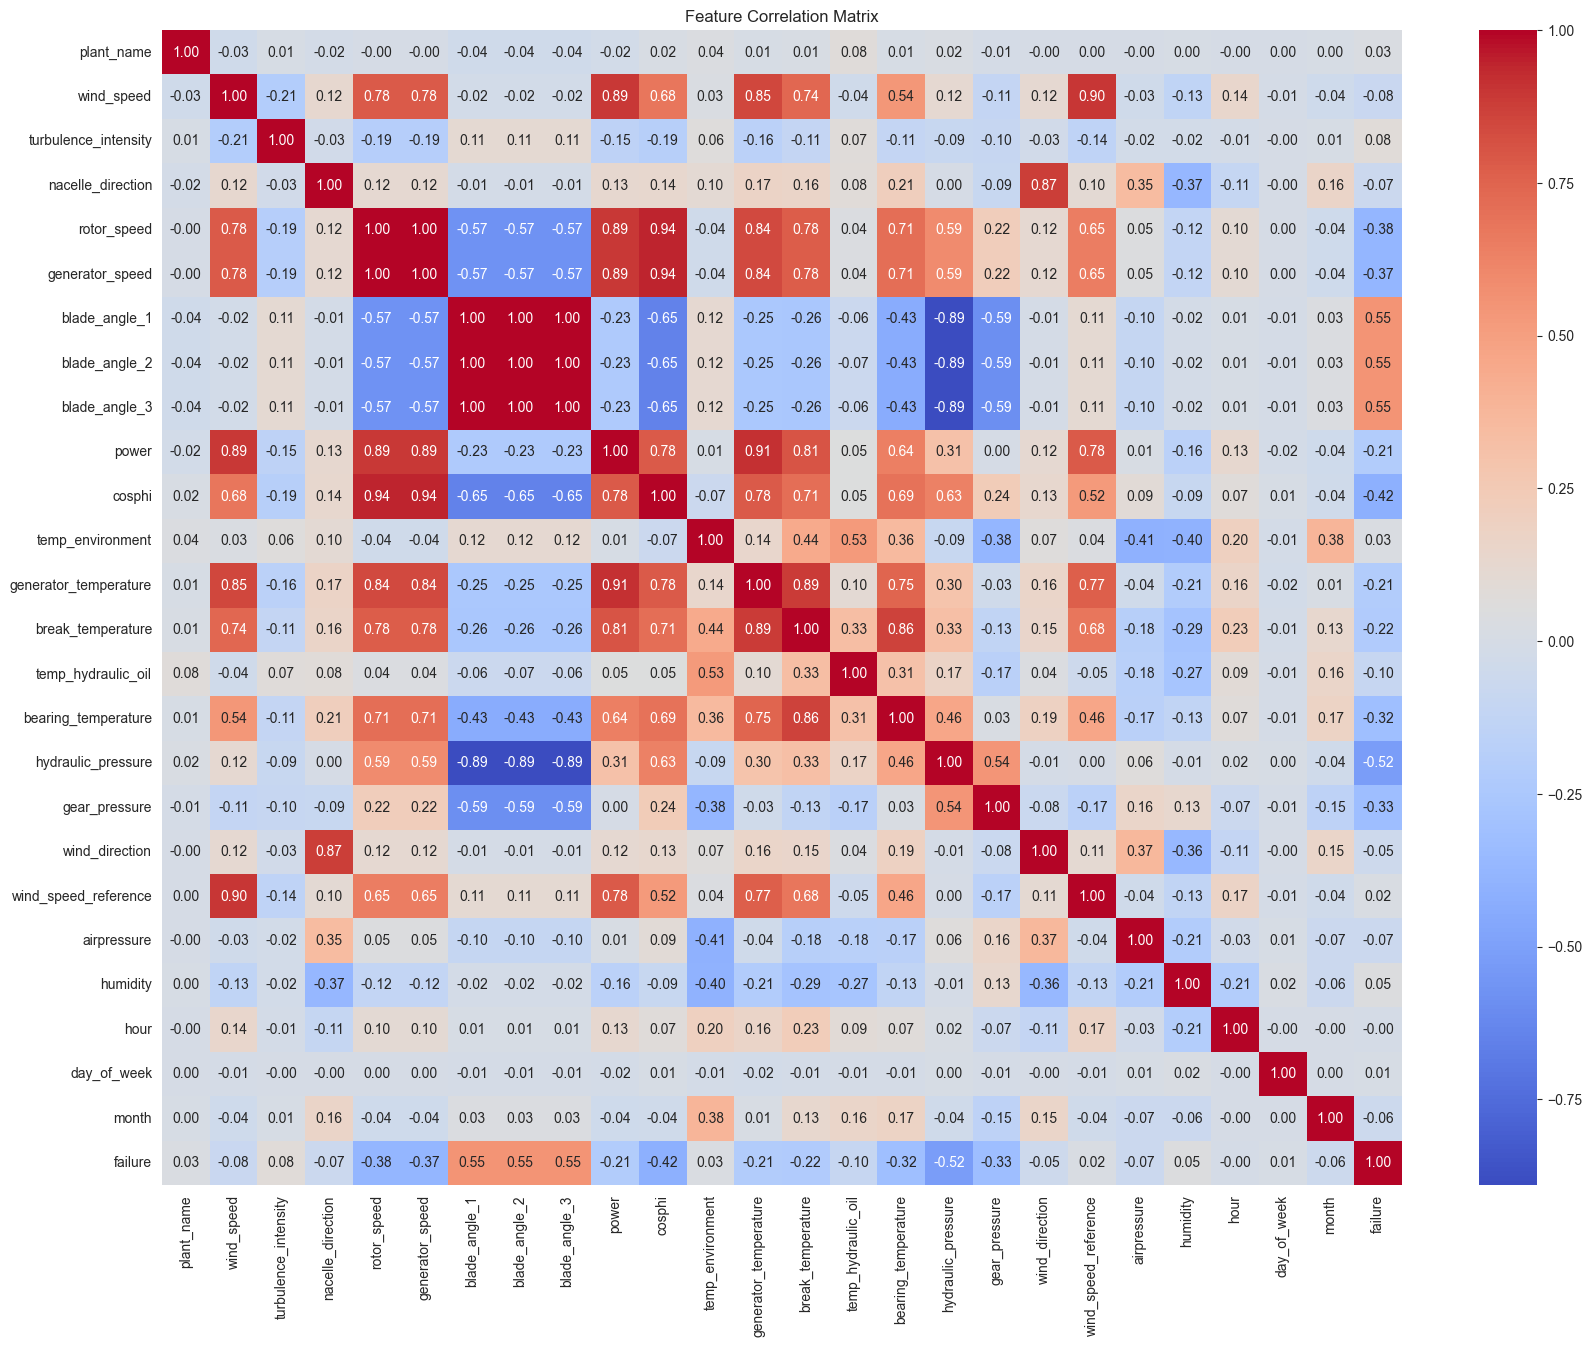

In [10]:
# Correlation analysis
plt.figure(figsize=(20, 15))
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()


In [11]:
# Isolation Forest for anomaly detection (can help identify important features)
iso_forest = IsolationForest(n_estimators=100, contamination='auto', random_state=42)
iso_forest.fit(X_scaled)
anomaly_scores = iso_forest.decision_function(X_scaled)

# Add anomaly scores to dataframe for analysis
data['anomaly_score'] = anomaly_scores

In [12]:
# Feature importance via Random Forest (unsupervised approach can use anomaly scores)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, data['anomaly_score'] < anomaly_scores.mean())  # Using anomaly threshold as pseudo-label

RandomForestClassifier(random_state=42)

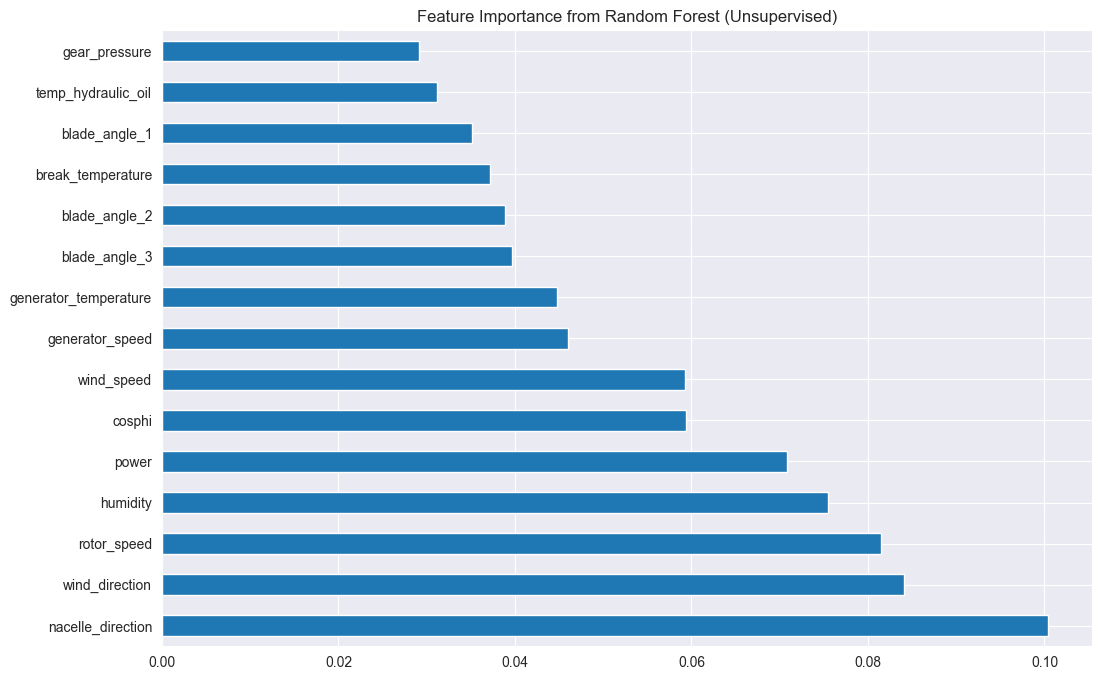

In [13]:
# Plot feature importance
plt.figure(figsize=(12, 8))
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh')
plt.title('Feature Importance from Random Forest (Unsupervised)')
plt.show()

In [14]:
# Select top k features based on mutual information
selector = SelectKBest(score_func=mutual_info_classif, k=10)
selector.fit(X_scaled, y)
selected_features = X.columns[selector.get_support()]

print("Selected Features based on Mutual Information:")
print(selected_features)


Selected Features based on Mutual Information:
Index(['nacelle_direction', 'rotor_speed', 'generator_speed', 'blade_angle_1',
       'blade_angle_2', 'blade_angle_3', 'power', 'cosphi',
       'hydraulic_pressure', 'gear_pressure'],
      dtype='object')


In [15]:
# PCA for dimensionality reduction
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_pca = pca.fit_transform(X_scaled)

print(f"\nOriginal number of features: {X_scaled.shape[1]}")
print(f"Reduced number of components: {X_pca.shape[1]}")


Original number of features: 25
Reduced number of components: 13


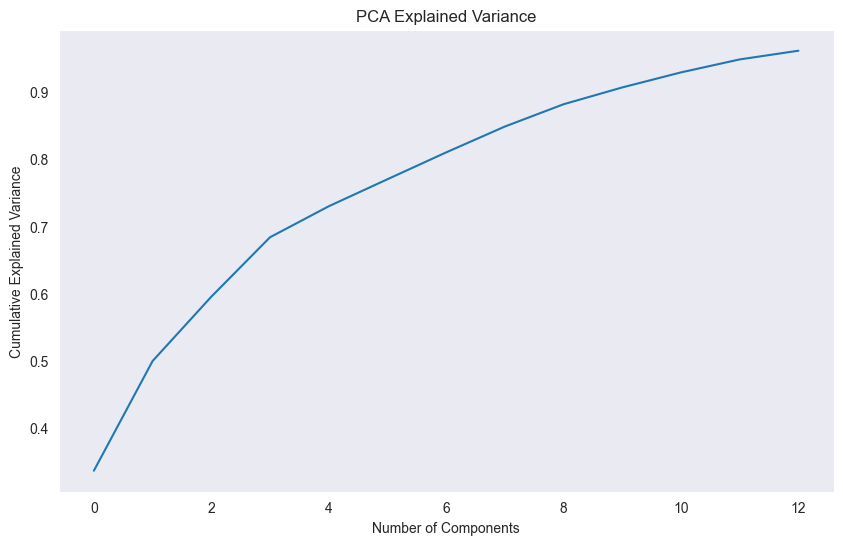

In [16]:
# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()


In [17]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train, y_train)

# Evaluate
y_pred = rf_clf.predict(X_test)
print("Random Forest Classifier Report:")
print(classification_report(y_test, y_pred))

Random Forest Classifier Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    137028
           1       0.99      0.90      0.95     19491

    accuracy                           0.99    156519
   macro avg       0.99      0.95      0.97    156519
weighted avg       0.99      0.99      0.99    156519



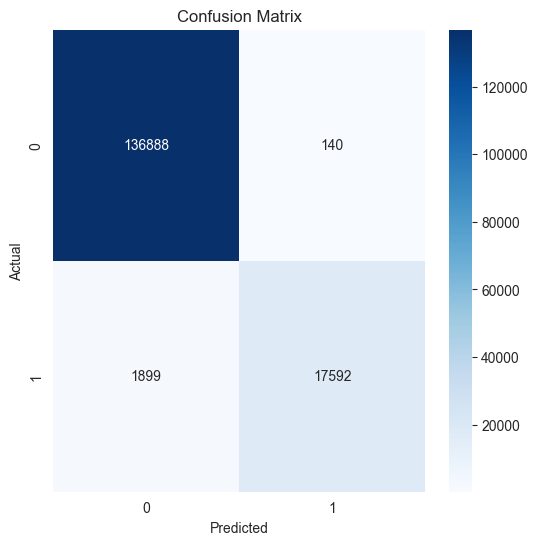

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

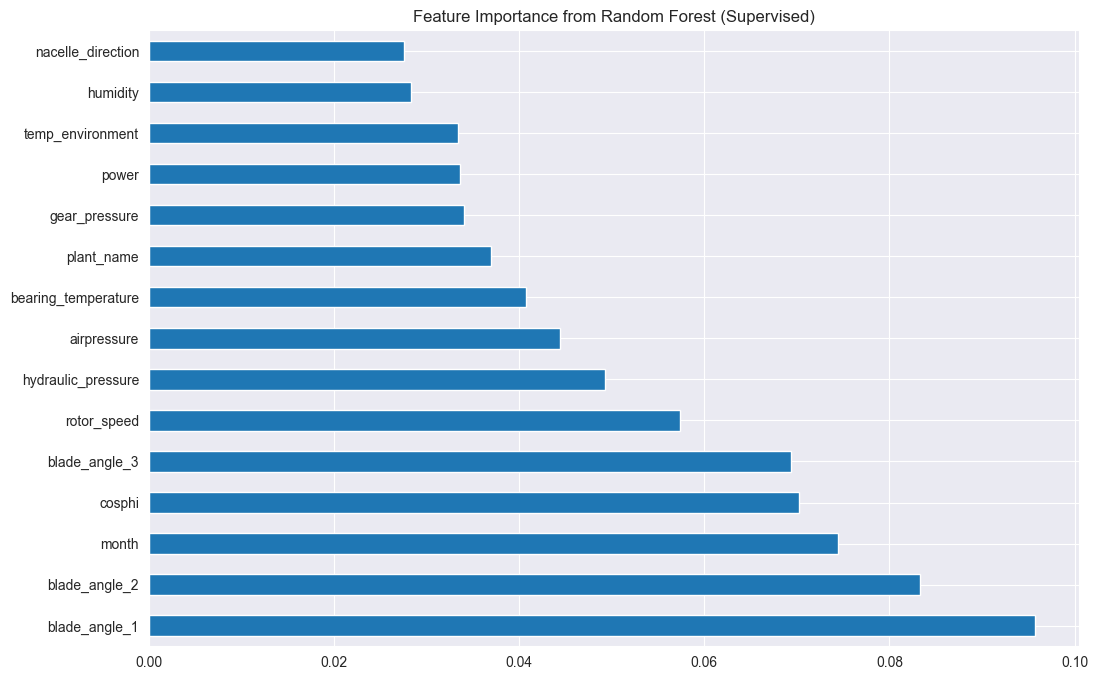

In [19]:
# Feature Importance
plt.figure(figsize=(12, 8))
feat_importances = pd.Series(rf_clf.feature_importances_, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh')
plt.title('Feature Importance from Random Forest (Supervised)')
plt.show()

In [21]:
# First, ensure X_test_sample is a DataFrame with proper column names
if isinstance(X_test_sample, np.ndarray):
    X_test_sample = pd.DataFrame(X_test_sample, columns=X.columns)

print("SHAP values shape:", np.array(shap_values).shape)
print("Test sample shape:", X_test_sample.shape)

SHAP values shape: (500, 25, 2)
Test sample shape: (500, 25)


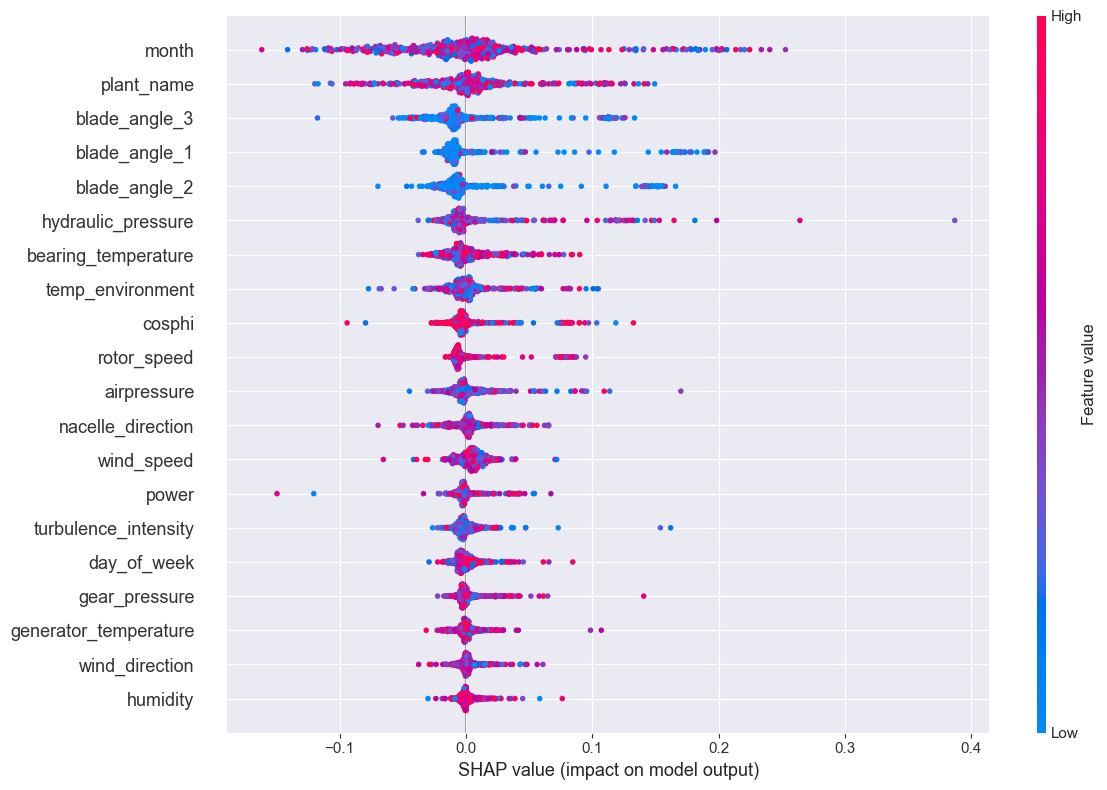

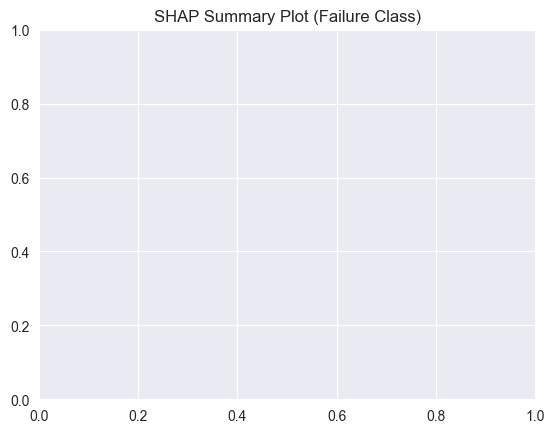

In [40]:
# Take a random subset of your test data (e.g., 100-1000 samples)
sample_idx = np.random.choice(X_test.shape[0], 500, replace=False)
X_test_sample = X_test[sample_idx]

# SHAP values on the subset
explainer = shap.TreeExplainer(rf_clf)

# 1. Convert SHAP values to the expected format
# For binary classification, we need to extract the SHAP values for class 1 (failure)
shap_values_class1 = np.array(shap_values)[:, :, 1]  # Shape (500, 25)

# 2. Ensure X_test_sample is a DataFrame with proper column names
if isinstance(X_test_sample, np.ndarray):
    X_test_sample = pd.DataFrame(X_test_sample, columns=X.columns)

# 3. Now plot correctly
plt.figure()
shap.summary_plot(shap_values_class1, X_test_sample, feature_names=X.columns, plot_size=(12, 8))
plt.title('SHAP Summary Plot (Failure Class)')
plt.show()

In [41]:

# Permutation Importance
#perm = PermutationImportance(rf_clf, random_state=42).fit(X_test, y_test)
#eli5.show_weights(perm, feature_names=X.columns.tolist())

KeyboardInterrupt: 

In [42]:
# Take a smaller random sample (e.g., 20% of test data)
sample_idx = np.random.choice(X_test.shape[0], int(X_test.shape[0]*0.2), replace=False)
X_test_sample = X_test[sample_idx]
y_test_sample = y_test.iloc[sample_idx]

perm = PermutationImportance(
    rf_clf,
    random_state=42,
    n_iter=5,  # Reduce from default 10 iterations
).fit(X_test_sample, y_test_sample)

eli5.show_weights(perm, feature_names=X.columns.tolist())

Weight,Feature
0.0582 ± 0.0007,month
0.0401 ± 0.0011,plant_name
0.0222 ± 0.0011,temp_environment
0.0206 ± 0.0004,airpressure
0.0199 ± 0.0006,bearing_temperature
0.0186 ± 0.0009,hydraulic_pressure
0.0133 ± 0.0007,blade_angle_3
0.0128 ± 0.0009,nacelle_direction
0.0121 ± 0.0009,day_of_week
0.0083 ± 0.0002,power


In [43]:
# ## 7. Advanced Model: XGBoost with Hyperparameter Tuning

# %%
# XGBoost Classifier with hyperparameter tuning
xgb = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)

params = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(xgb, params, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("Best XGBoost Parameters:", grid_search.best_params_)
print("\nXGBoost Classifier Report:")
print(classification_report(y_test, y_pred_xgb))


Best XGBoost Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}

XGBoost Classifier Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    137028
           1       0.98      0.94      0.96     19491

    accuracy                           0.99    156519
   macro avg       0.99      0.97      0.98    156519
weighted avg       0.99      0.99      0.99    156519



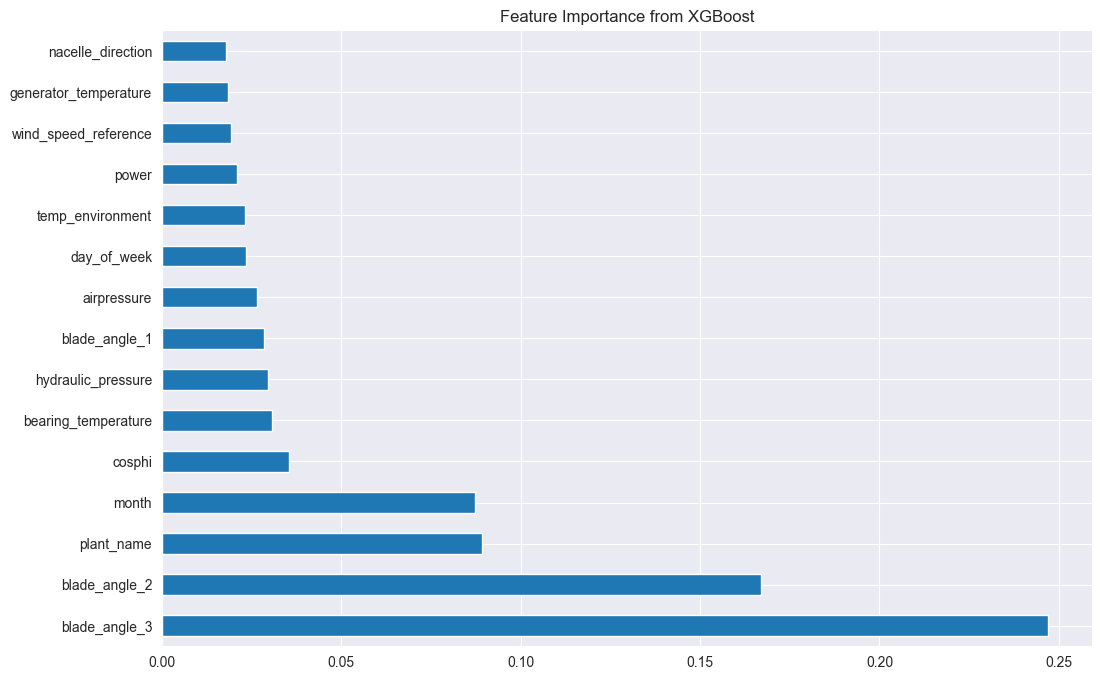

In [44]:
# Feature Importance
plt.figure(figsize=(12, 8))
feat_importances = pd.Series(best_xgb.feature_importances_, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh')
plt.title('Feature Importance from XGBoost')
plt.show()


In [48]:
# Check class balance
class_dist = pd.Series(y).value_counts(normalize=True)
print("Class distribution:\n", class_dist)

# If severe imbalance (e.g., <5% failures):
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Retrain model on balanced data
best_xgb.fit(X_resampled, y_resampled)

Class distribution:
 failure
0    0.875474
1    0.124526
Name: proportion, dtype: float64


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [49]:
def explain_prediction(instance_idx):
    print(f"\n=== Explanation for instance {instance_idx} ===")
    print(f"Actual class: {y_test.iloc[instance_idx]}")
    print(f"Predicted class: {y_pred_xgb[instance_idx]}")
    print(f"Predicted probability: {best_xgb.predict_proba(X_test[instance_idx:instance_idx+1])[0][1]:.2f}")

    # Ensure proper data formatting
    if isinstance(X_test, np.ndarray):
        instance_features = pd.DataFrame(X_test[instance_idx:instance_idx+1], columns=X.columns)
    else:
        instance_features = X_test.iloc[instance_idx:instance_idx+1]

    # Get SHAP values for this specific instance
    shap_values_instance = explainer.shap_values(instance_features)[1][0]  # For class 1 (failure)

    try:
        # Create force plot with proper dimensions
        display(shap.force_plot(
            explainer.expected_value[1],
            shap_values_instance,
            instance_features.iloc[0],
            feature_names=X.columns.tolist(),
            matplotlib=True
        ))
    except Exception as e:
        print(f"Could not create force plot: {str(e)}")
        # Fallback to bar plot
        plt.figure(figsize=(10, 5))
        shap.plots._waterfall.waterfall_legacy(
            explainer.expected_value[1],
            shap_values_instance,
            feature_names=X.columns.tolist()
        )
        plt.show()

    # Display feature values
    print("\nFeature Values:")
    display(instance_features.T.style.background_gradient(cmap='viridis'))

    # Highlight top contributing features
    top_contributors = pd.DataFrame({
        'Feature': X.columns,
        'SHAP Value': shap_values_instance,
        'Absolute Impact': np.abs(shap_values_instance)
    }).sort_values('Absolute Impact', ascending=False).head(5)

    print("\nTop 5 Contributing Features:")
    display(top_contributors)

# Explain instances with error handling
for idx in [10, 50, 100]:  # Example instances
    try:
        explain_prediction(idx)
    except Exception as e:
        print(f"Error explaining instance {idx}: {str(e)}")


=== Explanation for instance 10 ===
Actual class: 0
Predicted class: 0
Predicted probability: 0.04
Error explaining instance 10: index 1 is out of bounds for axis 0 with size 1

=== Explanation for instance 50 ===
Actual class: 0
Predicted class: 0
Predicted probability: 0.02
Error explaining instance 50: index 1 is out of bounds for axis 0 with size 1

=== Explanation for instance 100 ===
Actual class: 0
Predicted class: 0
Predicted probability: 0.00
Error explaining instance 100: index 1 is out of bounds for axis 0 with size 1


In [47]:
print("Class distribution in test set:")
print(y_test.value_counts())

print("\nPrediction distribution:")
print(pd.Series(best_xgb.predict_proba(X_test)[:,1]).describe())

Class distribution in test set:
failure
0    137028
1     19491
Name: count, dtype: int64

Prediction distribution:
count    1.565190e+05
mean     1.219814e-01
std      3.017440e-01
min      7.815475e-09
25%      1.549693e-04
50%      1.291150e-03
75%      1.346537e-02
max      1.000000e+00
dtype: float64


In [51]:
# Save the best model for deployment
import joblib
joblib.dump(best_xgb, 'wind_turbine_failure_predictor.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved for deployment.")

Model and scaler saved for deployment.


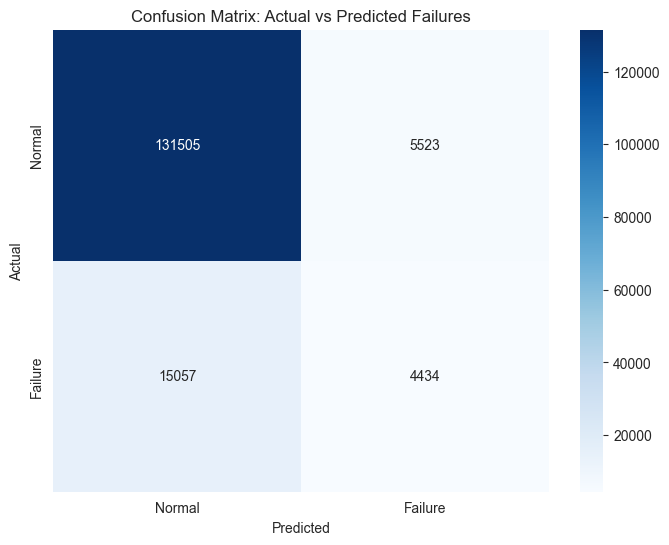

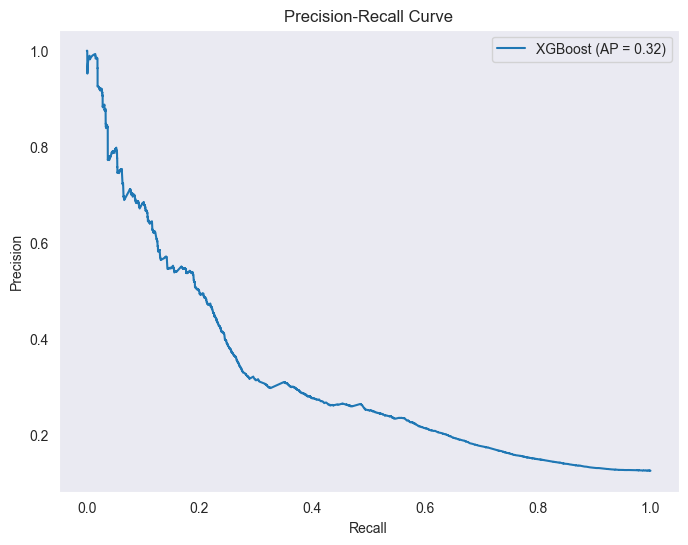

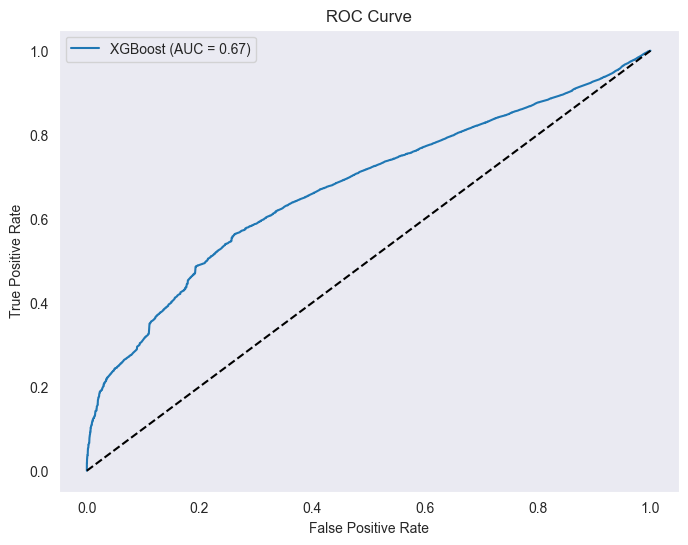


Detailed Performance Metrics:
              precision    recall  f1-score   support

      Normal       0.90      0.96      0.93    137028
     Failure       0.45      0.23      0.30     19491

    accuracy                           0.87    156519
   macro avg       0.67      0.59      0.61    156519
weighted avg       0.84      0.87      0.85    156519



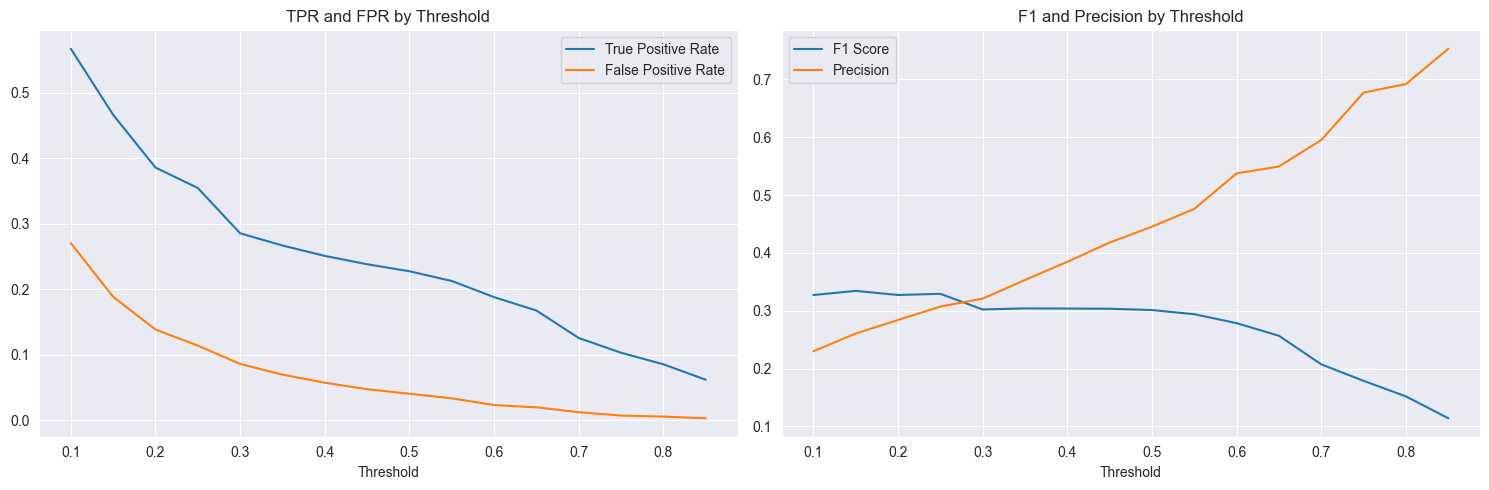


Analyzing 20580 misclassified cases:

15057 False Negatives (missed failures):


,Actual,Predicted,Failure_Probability
count,15057.0,15057.0,15057.000000
mean,1.0,0.0,0.113055
std,0.0,0.0,0.115642
min,1.0,0.0,0.000495
25%,1.0,0.0,0.015068
50%,1.0,0.0,0.070976
75%,1.0,0.0,0.169078
max,1.0,0.0,0.499882


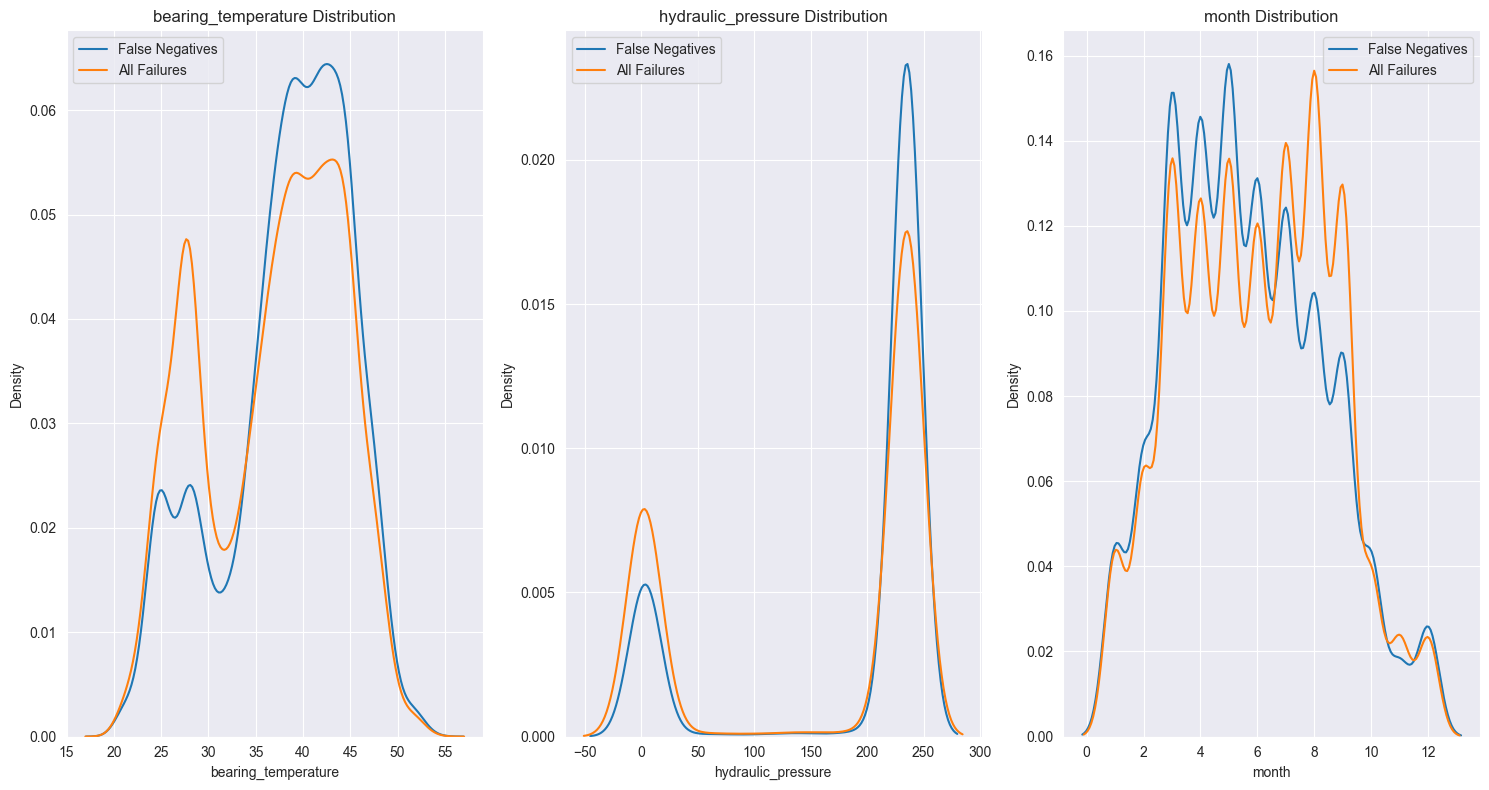


5523 False Positives (false alarms):


,Actual,Predicted,Failure_Probability
count,5523.0,5523.0,5523.000000
mean,0.0,1.0,0.655643
std,0.0,0.0,0.111853
min,0.0,1.0,0.500046
25%,0.0,1.0,0.561016
50%,0.0,1.0,0.641255
75%,0.0,1.0,0.713903
max,0.0,1.0,0.993495



Predictions saved to turbine_failure_predictions.csv


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                           precision_recall_curve, roc_curve, auc,
                           average_precision_score, precision_score,
                           f1_score)

# 1. Get predictions and probabilities
y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]  # Probability of failure

# 2. Create comparison dataframe
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Failure_Probability': y_proba
})

# 3. Time-based comparison (if timestamp available)
if 'timestamp' in data.columns:
    results['timestamp'] = pd.to_datetime(data['timestamp'].iloc[y_test.index])
    results.set_index('timestamp', inplace=True)

    # Plot daily failure rates
    plt.figure(figsize=(15, 6))
    results.resample('D')['Actual'].mean().plot(label='Actual Failure Rate')
    results.resample('D')['Failure_Probability'].mean().plot(label='Predicted Failure Probability')
    plt.title('Daily Actual vs Predicted Failure Rates')
    plt.ylabel('Failure Rate/Probability')
    plt.legend()
    plt.show()

# 4. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Failure'],
            yticklabels=['Normal', 'Failure'])
plt.title('Confusion Matrix: Actual vs Predicted Failures')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 5. Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'XGBoost (AP = {average_precision_score(y_test, y_proba):.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

# 6. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

# 7. Detailed Classification Report
print("\nDetailed Performance Metrics:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Failure']))

# 8. Threshold Analysis
thresholds = np.arange(0.1, 0.9, 0.05)
metrics = []
for thresh in thresholds:
    temp_pred = (y_proba > thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, temp_pred).ravel()
    metrics.append({
        'Threshold': thresh,
        'TPR': tp/(tp+fn),
        'FPR': fp/(fp+tn),
        'Precision': precision_score(y_test, temp_pred),
        'F1': f1_score(y_test, temp_pred)
    })

metrics_data = pd.DataFrame(metrics)
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(metrics_data['Threshold'], metrics_data['TPR'], label='True Positive Rate')
plt.plot(metrics_data['Threshold'], metrics_data['FPR'], label='False Positive Rate')
plt.xlabel('Threshold')
plt.title('TPR and FPR by Threshold')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(metrics_data['Threshold'], metrics_data['F1'], label='F1 Score')
plt.plot(metrics_data['Threshold'], metrics_data['Precision'], label='Precision')
plt.xlabel('Threshold')
plt.title('F1 and Precision by Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# 9. Feature Analysis for Misclassified Cases
misclassified = results[results['Actual'] != results['Predicted']]
if len(misclassified) > 0:
    print(f"\nAnalyzing {len(misclassified)} misclassified cases:")

    # False negatives (missed failures)
    fn = misclassified[misclassified['Actual'] == 1]
    if len(fn) > 0:
        print(f"\n{len(fn)} False Negatives (missed failures):")
        display(fn.describe())

        # Plot feature distributions for false negatives
        plt.figure(figsize=(15, 8))
        for i, col in enumerate(['bearing_temperature', 'hydraulic_pressure', 'month']):
            plt.subplot(1, 3, i+1)
            sns.kdeplot(data=data.loc[fn.index], x=col, label='False Negatives')
            sns.kdeplot(data=data.loc[y_test[y_test==1].index], x=col, label='All Failures')
            plt.title(f'{col} Distribution')
            plt.legend()
        plt.tight_layout()
        plt.show()

    # False positives (false alarms)
    fp = misclassified[misclassified['Actual'] == 0]
    if len(fp) > 0:
        print(f"\n{len(fp)} False Positives (false alarms):")
        display(fp.describe())

# 10. Save results for operational use
results.to_csv('turbine_failure_predictions.csv', index=False)
print("\nPredictions saved to turbine_failure_predictions.csv")